# Organic-Inorganic Combination — Option A / Option C / OOD Guard

Combines the project's two existing surrogates (a prior organic-aerosol surrogate for binary water-organic
systems, and this project's inorganic surrogate for water + 14-ion electrolyte systems) at the `aiomfac_py`
level, mirroring AIOMFAC's own additive SR+MR structure, instead of training one new joint model.

1. **Option A** — independent/additive combination: run each surrogate on its own binary sub-system, sum the
   water predictions, take each surrogate's own-species prediction as-is. Validated against real ternary
   water+organic+salt systems built directly in `aiomfac_py`.
2. **Option C** — residual-correction surrogate: keep Option A's sum as a first-order estimate, train one
   small MLP to predict the residual (true − Option A) for water, the organic, and the two ions. Includes a
   pool-widening experiment (9→58 training organics) to see whether more data alone fixes generalization.
3. **OOD guard** — a distance-based safeguard that applies the organic-species correction only when the
   query organic is close enough (in its own feature space) to the residual model's training pool, otherwise
   falling back to Option A's raw value.

Ground truth throughout is `aiomfac_py`'s own `ActivityModel.evaluate()` on real ternary systems — exact,
not approximate, since the library can already fully evaluate mixed organic+electrolyte systems.


**Setup.** This notebook expects `aiomfac-python/` (library source), `trained_model_dense/` (the
organic surrogate's saved weights -- the dense-composition-grid retrained checkpoint from Part 1 notebook Sec. 8), `training_data.parquet` (the inorganic surrogate's training data),
`organics.json` (the organic-molecule pool), and the two helper `.py` scripts next to it — that's what
`combo_bundle.zip` contains. The next cell finds them automatically: if they're not already present (e.g.
you only uploaded this notebook by itself into a fresh Colab machine), it looks for the bundle zip in the
working directory and, in Colab, offers an upload picker for it — then unzips it and `cd`s into it on its
own. No manual `os.chdir`/`unzip` needed.

In [1]:
# Locate (or fetch + unzip) the combo_bundle, then make this the working directory.
import os, zipfile
from pathlib import Path

def _find_bundle(start: Path):
    for base in (start, start.parent):
        if (base / "aiomfac-python").exists() and (base / "organics.json").exists():
            return base
    for cand in start.glob("*/aiomfac-python"):
        if (cand.parent / "organics.json").exists():
            return cand.parent
    return None

_base = _find_bundle(Path.cwd())

if _base is None:
    zip_candidates = sorted(Path.cwd().glob("*.zip"))
    if not zip_candidates:
        try:
            from google.colab import files  # only exists on Colab
            print("combo_bundle not found next to this notebook.")
            print("Select combo_bundle.zip to upload:")
            uploaded = files.upload()
            zip_candidates = [Path(name) for name in uploaded if name.endswith(".zip")]
        except ImportError:
            pass
    if zip_candidates:
        zpath = zip_candidates[0]
        print(f"Unzipping {zpath.name} ...")
        with zipfile.ZipFile(zpath) as zf:
            zf.extractall(".")
        _base = _find_bundle(Path.cwd())

if _base is None:
    raise FileNotFoundError(
        "Could not find or unzip combo_bundle. In Jupyter: upload combo_bundle.zip into this notebook's "
        "working directory via the file browser, then re-run this cell. In Colab, re-run this cell and use "
        "the upload picker it opens."
    )
os.chdir(_base)
print("Working directory set to:", Path.cwd())


Working directory set to: /home/claude/aiomfac-surrogates/part2_inorganic_surrogate/organic_inorganic_combination


In [2]:
# Install missing dependencies.
import subprocess, sys as _sys
for pkg, mod in [("torch", "torch"), ("numpy", "numpy"), ("pandas", "pandas"), ("pyarrow", "pyarrow"),
                  ("scipy", "scipy"), ("rdkit", "rdkit"), ("matplotlib", "matplotlib"),
                  ("epam.indigo", "indigo")]:
    try:
        __import__(mod)
    except ImportError:
        subprocess.run([_sys.executable, "-m", "pip", "install", "-q", pkg], check=True)


In [3]:
# Path setup.
import sys
from pathlib import Path

HERE = Path.cwd()
AIOMFAC_SRC = HERE / "aiomfac-python"
sys.path.insert(0, str(AIOMFAC_SRC / "src"))
sys.path.insert(0, str(AIOMFAC_SRC / "tools"))
sys.path.insert(0, str(HERE))

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from aiomfac_py import ActivityModel, Component
from aiomfac_py.params import load_subgroup_params
from aiomfac_py.s2as import smiles_to_components
from inorganic_component_basis import CATIONS, ANIONS

SG = load_subgroup_params()
CATION_NAMES = [n for n, _, _ in CATIONS]
ANION_NAMES = [n for n, _, _ in ANIONS]
ALL_IONS = CATION_NAMES + ANION_NAMES
IN_COLS = [f"m_{n}" for n in ALL_IONS] + ["T_K"]
OUT_COLS = ["ln_gamma_H2O"] + [f"ln_gamma_{n}" for n in ALL_IONS]
ION_SUB = {n: sub for n, sub, _ in CATIONS + ANIONS}
ION_Z = {n: z for n, _, z in CATIONS + ANIONS}
ION_MW = {name: float(SG.SMWC[sub - 201]) * 1e-3 for name, sub, _ in CATIONS}
ION_MW.update({name: float(SG.SMWA[sub - 241]) * 1e-3 for name, sub, _ in ANIONS})
print("Ion basis:", ALL_IONS)

# All models/tensors below move onto this device. Everything here is a small MLP
# (tens to hundreds of thousands of parameters) on datasets of a few thousand rows,
# so on most machines CPU is already fast (the whole notebook runs in a few minutes);
# this just lets it also use a GPU automatically when one is available (e.g. a Colab
# GPU runtime), with no behavior change otherwise.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


=== Finalized input vector spec (len=15) ===
  m_Na+      [mol/kg H2O]
  m_K+       [mol/kg H2O]
  m_NH4+     [mol/kg H2O]
  m_Ca2+     [mol/kg H2O]
  m_H+       [mol/kg H2O]
  m_Cl-      [mol/kg H2O]
  m_NO3-     [mol/kg H2O]
  m_SO4--    [mol/kg H2O]
  m_HSO4-    [mol/kg H2O]
  m_HCO3-    [mol/kg H2O]
  m_CO3--    [mol/kg H2O]
  m_IO3-     [mol/kg H2O]
  m_I-       [mol/kg H2O]
  m_OH-      [mol/kg H2O]
  T_K        [K]

=== Output vector spec (component ln(gamma), len=15) ===
  ln_gamma_H2O
  ln_gamma_Na+
  ln_gamma_K+
  ln_gamma_NH4+
  ln_gamma_Ca2+
  ln_gamma_H+
  ln_gamma_Cl-
  ln_gamma_NO3-
  ln_gamma_SO4--
  ln_gamma_HSO4-
  ln_gamma_HCO3-
  ln_gamma_CO3--
  ln_gamma_IO3-
  ln_gamma_I-
  ln_gamma_OH-

Ion basis: ['Na+', 'K+', 'NH4+', 'Ca2+', 'H+', 'Cl-', 'NO3-', 'SO4--', 'HSO4-', 'HCO3-', 'CO3--', 'IO3-', 'I-', 'OH-']
Using device: cpu


## Step 1 — Load the two existing surrogates

In [4]:
class OrganicMLP(nn.Module):
    """Organic surrogate: 24-dim hand-crafted feature vector -> [ln_gamma_H2O, ln_gamma_organic]
    for a binary water-organic system."""
    def __init__(self, n_in, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, x):
        return self.net(x)


# Uses the dense-composition-grid retrained organic surrogate (Part 1 notebook, Sec. 8)
# throughout this notebook, not the original trained_model_delivered/ -- it is more accurate
# on the worked examples in Sec. 4.5 below and is used consistently for every Option A/C/guard
# result in this notebook (Tables 5-9).
ORG_DIR = HERE / "trained_model_dense"
org_meta = json.load(open(ORG_DIR / "surrogate_meta.json"))
org_norm = np.load(ORG_DIR / "surrogate_norm.npz")
org_model = OrganicMLP(org_meta["n_features"]).to(DEVICE)
org_model.load_state_dict(torch.load(ORG_DIR / "surrogate_weights.pt", map_location="cpu"))
org_model.eval()
print(f"Organic surrogate loaded: {org_meta['n_organics']} training molecules, "
      f"gen. MAE water={org_meta['sanity_gen_mae']['water']:.3f}, organic={org_meta['sanity_gen_mae']['organic']:.3f}")


Organic surrogate loaded: 368 training molecules, gen. MAE water=0.023, organic=0.288


In [5]:
class InorganicMLP(nn.Module):
    """Inorganic surrogate: 15-dim nominal-molality vector (14 ions + T) -> ln_gamma for water + 14 ions."""
    def __init__(self, n_in, n_out, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, n_out),
        )

    def forward(self, x):
        return self.net(x)


def featurize_inorganic(df, mu=None, sd=None):
    X = np.log1p(df[IN_COLS[:-1]].to_numpy(dtype=np.float32))
    T = df["T_K"].to_numpy(dtype=np.float32)[:, None]
    X = np.concatenate([X, T], axis=1)
    if mu is None:
        mu, sd = X.mean(axis=0), X.std(axis=0) + 1e-8
    Xs = (X - mu) / sd
    Y = df[OUT_COLS].to_numpy(dtype=np.float32)
    mask = np.isfinite(Y).astype(np.float32)
    Y = np.nan_to_num(Y, nan=0.0)
    return Xs, Y, mask, mu, sd


def masked_mse(pred, target, mask):
    diff2 = (pred - target) ** 2 * mask
    return diff2.sum() / mask.sum().clamp(min=1.0)


def train_inorganic_surrogate(data_path, epochs=400, patience=25, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    df = pd.read_parquet(data_path)
    df = df[df[OUT_COLS[1:]].notna().any(axis=1)].reset_index(drop=True)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df))
    n_val = int(0.1 * len(df))
    df_interp, df_train = df.iloc[idx[:n_val]].reset_index(drop=True), df.iloc[idx[n_val:]].reset_index(drop=True)

    Xtr, Ytr, Mtr, mu, sd = featurize_inorganic(df_train)
    Xva, Yva, Mva, _, _ = featurize_inorganic(df_interp, mu, sd)
    model = InorganicMLP(Xtr.shape[1], Ytr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xtr_t, Ytr_t, Mtr_t = (torch.from_numpy(a).to(DEVICE) for a in (Xtr, Ytr, Mtr))
    Xva_t, Yva_t, Mva_t = (torch.from_numpy(a).to(DEVICE) for a in (Xva, Yva, Mva))

    best_val, best_state, bad = float("inf"), None, 0
    for epoch in range(epochs):
        model.train(); opt.zero_grad()
        loss = masked_mse(model(Xtr_t), Ytr_t, Mtr_t)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = masked_mse(model(Xva_t), Yva_t, Mva_t).item()
        if vloss < best_val - 1e-6:
            best_val, best_state, bad = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad > patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model, (mu, sd), best_val


inorg_model, inorg_scaler, inorg_best_val = train_inorganic_surrogate(HERE / "training_data.parquet")
print(f"Inorganic surrogate retrained (no checkpoint was ever saved to disk for it): "
      f"best val (masked MSE) = {inorg_best_val:.4f}")


Inorganic surrogate retrained (no checkpoint was ever saved to disk for it): best val (masked MSE) = 0.0846


## Step 2 — Organic surrogate feature construction

Builds the organic surrogate's 22-dim functional-group-fraction + descriptor feature vector for a given
SMILES string, matching how the delivered model (`trained_model_delivered/`) was trained.

In [6]:
def organic_mg_features(smiles):
    from rdkit import Chem
    r = smiles_to_components([smiles], water_as_component1=True)
    if r.removed:
        raise ValueError(f"SMILES decomposition failed for {smiles}: {r.removed}")
    organic = r.components[1]
    subgroups = organic.subgroups

    main_groups = org_meta["main_groups"]
    mg_index = {g: i for i, g in enumerate(main_groups)}
    mg_counts = np.zeros(len(main_groups))
    total_q = 0
    for s, q in subgroups:
        mg = SG.main_group(int(s))
        mg_counts[mg_index[mg]] += q
        total_q += q
    mg_frac = mg_counts / max(total_q, 1)

    mol = Chem.MolFromSmiles(smiles)
    mol_h = Chem.AddHs(mol)
    n_c = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "C")
    n_o = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "O")
    n_n = sum(1 for a in mol_h.GetAtoms() if a.GetSymbol() == "N")
    mw = sum(a.GetMass() for a in mol_h.GetAtoms())
    feat22 = np.concatenate([mg_frac, [n_o / max(n_c, 1), n_n / max(n_c, 1), np.log(mw), np.log1p(total_q)]])
    return feat22.astype(np.float32), subgroups


def organic_predict(feat22, wtf_water_binary, T_K):
    T_norm = (T_K - 293.15) / 20.0
    x = np.concatenate([feat22, [wtf_water_binary, T_norm]]).astype(np.float32)
    xn = (x - org_norm["x_mean"]) / org_norm["x_std"]
    with torch.no_grad():
        yn = org_model(torch.from_numpy(xn[None, :]).to(DEVICE)).cpu().numpy()[0]
    y = yn * org_norm["y_std"] + org_norm["y_mean"]
    return float(y[0]), float(y[1])


def inorganic_predict(ion_molality, T_K):
    mu, sd = inorg_scaler
    row = {f"m_{n}": ion_molality.get(n, 0.0) for n in ALL_IONS}
    row["T_K"] = T_K
    df = pd.DataFrame([row])
    X = np.log1p(df[IN_COLS[:-1]].to_numpy(dtype=np.float32))
    X = np.concatenate([X, df[["T_K"]].to_numpy(dtype=np.float32)], axis=1)
    Xs = (X - mu) / sd
    with torch.no_grad():
        pred = inorg_model(torch.from_numpy(Xs).to(DEVICE)).cpu().numpy()[0]
    return {col: float(v) for col, v in zip(OUT_COLS, pred)}


def salt_stoich(z_cat, z_an):
    import math
    g = math.gcd(abs(z_cat), abs(z_an))
    return abs(z_an) // g, abs(z_cat) // g


def ternary_ground_truth(smiles, organic_name, subgroups, cat_name, an_name, wtf_organic, wtf_salt, T_K):
    """Real water+organic+salt ternary, evaluated by aiomfac_py -- the exact ground truth."""
    water = Component(1, "Water", ((16, 1),))
    organic = Component(2, organic_name, tuple((int(s), q) for s, q in subgroups))
    qc, qa = salt_stoich(ION_Z[cat_name], ION_Z[an_name])
    salt = Component(3, f"{cat_name}{an_name}", ((ION_SUB[cat_name], qc), (ION_SUB[an_name], qa)))
    model = ActivityModel([water, organic, salt])
    res = model.evaluate([0.0, wtf_organic, wtf_salt], T_K, basis="mass")
    if not np.all(np.isfinite(res.ln_gamma)):
        return None
    sr = model.mixture.sr
    nn_, nc = sr.n_neutral, sr.n_cation
    out = {"ln_gamma_H2O": float(res.ln_gamma[0]), "ln_gamma_organic": float(res.ln_gamma[1])}
    for n in (cat_name, an_name):
        sub = ION_SUB[n]
        if sub in sr.cations:
            out[f"ln_gamma_{n}"] = float(res.ln_gamma[nn_ + sr.cations.index(sub)])
        elif sub in sr.anions:
            out[f"ln_gamma_{n}"] = float(res.ln_gamma[nn_ + nc + sr.anions.index(sub)])

    wtf_water = 1.0 - wtf_organic - wtf_salt
    mw_salt = qc * ION_MW[cat_name] + qa * ION_MW[an_name]
    n_salt_mol = wtf_salt / mw_salt
    ctx = {"wtf_water": wtf_water, "wtf_organic": wtf_organic, "wtf_salt": wtf_salt,
           "molal_cat": n_salt_mol * qc / wtf_water, "molal_an": n_salt_mol * qa / wtf_water}
    return out, ctx


def option_a_predict(feat22, cat_name, an_name, ctx, T_K):
    wtf_water, wtf_organic = ctx["wtf_water"], ctx["wtf_organic"]
    wtf_water_org_binary = wtf_water / (wtf_water + wtf_organic)
    lgw_org, lgo = organic_predict(feat22, wtf_water_org_binary, T_K)
    ion_molal = {cat_name: ctx["molal_cat"], an_name: ctx["molal_an"]}
    pred_inorg = inorganic_predict(ion_molal, T_K)
    return {"ln_gamma_H2O": lgw_org + pred_inorg["ln_gamma_H2O"], "ln_gamma_organic": lgo,
            f"ln_gamma_{cat_name}": pred_inorg[f"ln_gamma_{cat_name}"],
            f"ln_gamma_{an_name}": pred_inorg[f"ln_gamma_{an_name}"]}


print("Option A / ground-truth helper functions ready.")


Option A / ground-truth helper functions ready.


## Step 3 — Option A: validate the independent-sum baseline

Builds real water+organic+salt ternary systems directly in `aiomfac_py` across a composition/temperature
grid, and compares Option A's additive-sum prediction to the true ternary values.

In [7]:
organics_json = json.load(open(HERE / "organics.json"))
by_name = {d["name"]: d for d in organics_json}

test_organics = [n for n in ["glucose", "citric acid", "glycerol", "sucrose", "levoglucosan", "ethanol"] if n in by_name]
salts = [("Na+", "Cl-"), ("NH4+", "SO4--"), ("Ca2+", "NO3-")]
wtf_organic_grid = [0.05, 0.15, 0.30]
wtf_salt_grid = [0.02, 0.08]
T_grid = [283.15, 298.15, 313.15]

rows = []
for oname in test_organics:
    d = by_name[oname]
    feat22, subgroups = organic_mg_features(d["smiles"])
    for cat_name, an_name in salts:
        for wtf_o in wtf_organic_grid:
            for wtf_s in wtf_salt_grid:
                if wtf_o + wtf_s >= 0.9:
                    continue
                for T_K in T_grid:
                    gt = ternary_ground_truth(d["smiles"], oname, subgroups, cat_name, an_name, wtf_o, wtf_s, T_K)
                    if gt is None:
                        continue
                    truth, ctx = gt
                    pred = option_a_predict(feat22, cat_name, an_name, ctx, T_K)
                    row = {"organic": oname, "salt": f"{cat_name}{an_name}", "wtf_organic": wtf_o,
                           "wtf_salt": wtf_s, "T_K": T_K}
                    for sp in ["ln_gamma_H2O", "ln_gamma_organic", f"ln_gamma_{cat_name}", f"ln_gamma_{an_name}"]:
                        row[f"truth_{sp}"] = truth.get(sp, np.nan)
                        row[f"pred_{sp}"] = pred.get(sp, np.nan)
                        row[f"abserr_{sp}"] = abs(row[f"truth_{sp}"] - row[f"pred_{sp}"])
                    rows.append(row)

df_a = pd.DataFrame(rows)
print(f"Built {len(df_a)} ternary grid points.")
print(f"Option A MAE -- H2O: {df_a['abserr_ln_gamma_H2O'].mean():.4f}   "
      f"organic: {df_a['abserr_ln_gamma_organic'].mean():.4f}")
ion_cols = [c for c in df_a.columns if c.startswith("abserr_ln_gamma_") and c not in
            ("abserr_ln_gamma_H2O", "abserr_ln_gamma_organic")]
ion_errs = pd.concat([df_a[c].dropna() for c in ion_cols])
print(f"Option A MAE -- ions (pooled): {ion_errs.mean():.4f}")


Built 324 ternary grid points.
Option A MAE -- H2O: 0.0390   organic: 0.3734
Option A MAE -- ions (pooled): 0.5304


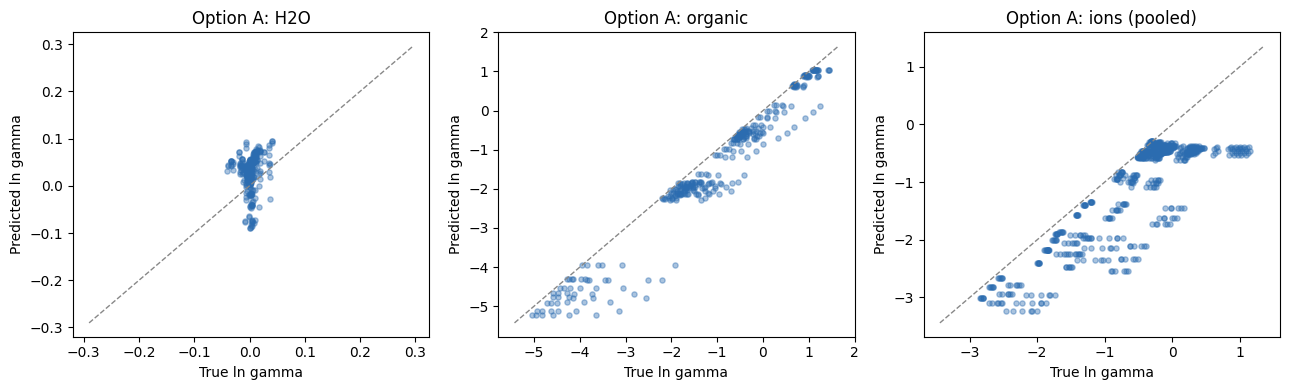

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col, title) in zip(axes, [("ln_gamma_H2O", "H2O"), ("ln_gamma_organic", "organic"), (None, "ions (pooled)")]):
    if col:
        t, p = df_a[f"truth_{col}"], df_a[f"pred_{col}"]
    else:
        t = pd.concat([df_a[f"truth_ln_gamma_{s}"] for pair in salts for s in pair if f"truth_ln_gamma_{s}" in df_a])
        p = pd.concat([df_a[f"pred_ln_gamma_{s}"] for pair in salts for s in pair if f"pred_ln_gamma_{s}" in df_a])
    ax.scatter(t, p, s=14, alpha=0.4, color="#2b6cb0")
    lims = [min(t.min(), p.min()) - 0.2, max(t.max(), p.max()) + 0.2]
    ax.plot(lims, lims, "--", color="#888", linewidth=1)
    ax.set_title(f"Option A: {title}"); ax.set_xlabel("True ln gamma"); ax.set_ylabel("Predicted ln gamma")
fig.tight_layout(); plt.show()


## Step 4 — Option C: train the residual-correction model

Trains a small MLP to predict the residual (true ternary value − Option A's prediction) for
[ln gamma(H2O), ln gamma(organic), ln gamma(cation), ln gamma(anion)]. Uses a widened pool (oxygenated
organics only, the chemistry class the organic surrogate was actually trained on) with some organics and
salts held out ENTIRELY for an honest generalization test.

In [9]:
class ResidualMLP(nn.Module):
    def __init__(self, n_in, hidden=96):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, 4))

    def forward(self, x):
        return self.net(x)


def oxygenated_names(organics_json, limit=70):
    from rdkit import Chem
    names = []
    for d in organics_json:
        mol = Chem.MolFromSmiles(d["smiles"])
        if mol is not None and any(a.GetSymbol() == "O" for a in mol.GetAtoms()):
            names.append(d["name"])
        if len(names) >= limit:
            break
    return names


SALTS_TRAIN = [("Na+", "Cl-"), ("Na+", "NO3-"), ("K+", "Cl-"), ("NH4+", "SO4--"),
               ("Ca2+", "NO3-"), ("H+", "Cl-"), ("Na+", "SO4--"), ("K+", "NO3-")]
SALTS_GEN = [("NH4+", "Cl-"), ("NH4+", "NO3-")]
WTF_O_GRID, WTF_S_GRID, T_GRID2 = [0.08, 0.20, 0.30], [0.03, 0.08], [283.15, 313.15]

names70 = oxygenated_names(organics_json, limit=70)
gen_idx = set(range(0, len(names70), 6))
organics_gen = [n for i, n in enumerate(names70) if i in gen_idx]
organics_train = [n for i, n in enumerate(names70) if i not in gen_idx]
print(f"Residual-model pool: {len(organics_train)} train / {len(organics_gen)} held-out-entirely organics, "
      f"{len(SALTS_TRAIN)} train / {len(SALTS_GEN)} held-out-entirely salts")


Residual-model pool: 58 train / 12 held-out-entirely organics, 8 train / 2 held-out-entirely salts


In [10]:
def build_residual_dataset(organics, salts_list, tag=""):
    rows = []
    for oname in organics:
        if oname not in by_name:
            continue
        d = by_name[oname]
        try:
            feat22, subgroups = organic_mg_features(d["smiles"])
        except Exception:
            continue
        for cat_name, an_name in salts_list:
            for wtf_o in WTF_O_GRID:
                for wtf_s in WTF_S_GRID:
                    if wtf_o + wtf_s >= 0.85:
                        continue
                    for T_K in T_GRID2:
                        gt = ternary_ground_truth(d["smiles"], oname, subgroups, cat_name, an_name, wtf_o, wtf_s, T_K)
                        if gt is None:
                            continue
                        truth, ctx = gt
                        pred = option_a_predict(feat22, cat_name, an_name, ctx, T_K)
                        T_norm = (T_K - 293.15) / 20.0
                        cat_oh = [1.0 if n == cat_name else 0.0 for n in CATION_NAMES]
                        an_oh = [1.0 if n == an_name else 0.0 for n in ANION_NAMES]
                        x = np.concatenate([feat22, [wtf_o, wtf_s, T_norm, np.log1p(ctx["molal_cat"]),
                                                      np.log1p(ctx["molal_an"])], cat_oh, an_oh]).astype(np.float32)
                        y = np.array([truth["ln_gamma_H2O"] - pred["ln_gamma_H2O"],
                                      truth["ln_gamma_organic"] - pred["ln_gamma_organic"],
                                      truth[f"ln_gamma_{cat_name}"] - pred[f"ln_gamma_{cat_name}"],
                                      truth[f"ln_gamma_{an_name}"] - pred[f"ln_gamma_{an_name}"]], dtype=np.float32)
                        rows.append({"x": x, "y": y, "organic": oname, "salt": f"{cat_name}{an_name}",
                                     "truth_H2O": truth["ln_gamma_H2O"], "pred_H2O": pred["ln_gamma_H2O"],
                                     "truth_organic": truth["ln_gamma_organic"], "pred_organic": pred["ln_gamma_organic"],
                                     "truth_cation": truth[f"ln_gamma_{cat_name}"], "pred_cation": pred[f"ln_gamma_{cat_name}"],
                                     "truth_anion": truth[f"ln_gamma_{an_name}"], "pred_anion": pred[f"ln_gamma_{an_name}"]})
    print(f"  [{tag}] built {len(rows)} points")
    return rows


print("Building residual-model training pool ...")
train_rows = build_residual_dataset(organics_train, SALTS_TRAIN, "train pool")
print("Building held-out generalization pools ...")
gen_rows = build_residual_dataset(organics_train, SALTS_GEN, "unseen salt only")
gen_rows += build_residual_dataset(organics_gen, SALTS_TRAIN, "unseen organic only")
gen_both_unseen = build_residual_dataset(organics_gen, SALTS_GEN, "unseen organic AND salt")
gen_rows += gen_both_unseen


Building residual-model training pool ...


Number of non-H atoms not matched to any AIOMFAC subgroup: 02


  [train pool] built 5568 points
Building held-out generalization pools ...


Number of non-H atoms not matched to any AIOMFAC subgroup: 02


  [unseen salt only] built 1392 points


  [unseen organic only] built 1152 points


  [unseen organic AND salt] built 288 points


In [11]:
rng = np.random.default_rng(0)
idx = rng.permutation(len(train_rows))
n_val = int(0.15 * len(train_rows))
val_idx, fit_idx = idx[:n_val], idx[n_val:]

Xall = np.stack([r["x"] for r in train_rows])
Yall = np.stack([r["y"] for r in train_rows])
x_mean, x_std = Xall[fit_idx].mean(0), Xall[fit_idx].std(0) + 1e-6
y_mean, y_std = Yall[fit_idx].mean(0), Yall[fit_idx].std(0) + 1e-6
Xn, Yn = (Xall - x_mean) / x_std, (Yall - y_mean) / y_std
Xfit_t, Yfit_t = torch.from_numpy(Xn[fit_idx]).to(DEVICE), torch.from_numpy(Yn[fit_idx]).to(DEVICE)
Xval_t, Yval_t = torch.from_numpy(Xn[val_idx]).to(DEVICE), torch.from_numpy(Yn[val_idx]).to(DEVICE)

torch.manual_seed(0)
resid_model = ResidualMLP(Xall.shape[1]).to(DEVICE)
opt = torch.optim.Adam(resid_model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
best_val, best_state, bad = float("inf"), None, 0
for epoch in range(800):
    resid_model.train()
    perm = np.random.permutation(len(fit_idx))
    for s in range(0, len(perm), 256):
        b = perm[s:s + 256]
        opt.zero_grad()
        loss = loss_fn(resid_model(Xfit_t[b]), Yfit_t[b])
        loss.backward(); opt.step()
    resid_model.eval()
    with torch.no_grad():
        vloss = loss_fn(resid_model(Xval_t), Yval_t).item()
    if vloss < best_val - 1e-6:
        best_val, best_state, bad = vloss, {k: v.clone() for k, v in resid_model.state_dict().items()}, 0
    else:
        bad += 1
        if bad > 50:
            break
resid_model.load_state_dict(best_state)
resid_model.eval()
print(f"Residual model trained, best val (normalized MSE) = {best_val:.5f}")

def predict_residual(X):
    xn = (X - x_mean) / x_std
    with torch.no_grad():
        yn = resid_model(torch.from_numpy(xn.astype(np.float32)).to(DEVICE)).cpu().numpy()
    return yn * y_std + y_mean


Residual model trained, best val (normalized MSE) = 0.00133


In [12]:
def evaluate_option_c(rows, label):
    if not rows:
        print(f"[{label}] no rows"); return
    X = np.stack([r["x"] for r in rows])
    resid_pred = predict_residual(X)
    print(f"\n=== {label} (n={len(rows)}) ===")
    for i, sp in enumerate(["H2O", "organic", "cation", "anion"]):
        truth = np.array([r[f"truth_{sp}"] for r in rows])
        pred_a = np.array([r[f"pred_{sp}"] for r in rows])
        pred_c = pred_a + resid_pred[:, i]
        mae_a, mae_c = np.mean(np.abs(truth - pred_a)), np.mean(np.abs(truth - pred_c))
        red = 100 * (1 - mae_c / mae_a) if mae_a > 0 else float("nan")
        print(f"  {sp:10s}  Option A MAE={mae_a:.4f}   Option C MAE={mae_c:.4f}   (reduction {red:.0f}%)")

interp_rows = [train_rows[i] for i in val_idx]
evaluate_option_c(interp_rows, "INTERPOLATION (seen organics x seen salts, held-out composition/T)")
evaluate_option_c(gen_rows, "GENERALIZATION -- all held-out-entirely cases combined")



=== INTERPOLATION (seen organics x seen salts, held-out composition/T) (n=835) ===
  H2O         Option A MAE=0.0529   Option C MAE=0.0018   (reduction 97%)
  organic     Option A MAE=0.8964   Option C MAE=0.0335   (reduction 96%)
  cation      Option A MAE=1.0209   Option C MAE=0.0134   (reduction 99%)
  anion       Option A MAE=0.5672   Option C MAE=0.0090   (reduction 98%)

=== GENERALIZATION -- all held-out-entirely cases combined (n=2832) ===
  H2O         Option A MAE=0.0504   Option C MAE=0.0348   (reduction 31%)
  organic     Option A MAE=0.7126   Option C MAE=0.3257   (reduction 54%)
  cation      Option A MAE=0.8214   Option C MAE=0.0777   (reduction 91%)
  anion       Option A MAE=0.5600   Option C MAE=0.0858   (reduction 85%)


## Step 5 — Out-of-distribution guard for the organic correction

Widening the pool fixed generalization for water and ions, but not for the organic's own prediction on a
genuinely unseen organic (see the printed numbers above). This step adds a simple safeguard: skip the
organic-species correction when the query organic is too far (in the organic surrogate's own feature space)
from the residual model's training pool.

In [13]:
def feat22_of(name):
    d = by_name[name]
    feat22, _ = organic_mg_features(d["smiles"])
    return feat22

train_feats = np.stack([feat22_of(n) for n in organics_train])
f_mean, f_std = train_feats.mean(0), train_feats.std(0) + 1e-6
train_feats_n = (train_feats - f_mean) / f_std

def nn_distance(name):
    f = (feat22_of(name) - f_mean) / f_std
    return float(np.sqrt(((train_feats_n - f[None, :]) ** 2).sum(axis=1)).min())

gen_dist = {n: nn_distance(n) for n in organics_gen}

per_organic = {}
for n in organics_gen:
    rows = [r for r in gen_rows if r["organic"] == n]
    if not rows:
        continue
    X = np.stack([r["x"] for r in rows])
    resid = predict_residual(X)
    truth = np.array([r["truth_organic"] for r in rows])
    pred_a = np.array([r["pred_organic"] for r in rows])
    pred_c = pred_a + resid[:, 1]
    mae_a, mae_c = float(np.mean(np.abs(truth - pred_a))), float(np.mean(np.abs(truth - pred_c)))
    per_organic[n] = {"dist": gen_dist[n], "helps": mae_c < mae_a,
                       "reduction_pct": 100 * (1 - mae_c / mae_a) if mae_a > 0 else np.nan}

dists = np.array([v["dist"] for v in per_organic.values()])
helps = np.array([v["helps"] for v in per_organic.values()])
best_t, best_score = None, -1
for t in np.unique(dists):
    keep = dists <= t
    score = np.sum(helps[keep]) + np.sum(~helps[~keep])
    if score > best_score:
        best_score, best_t = score, t
print(f"Calibrated OOD guard threshold: nn_distance <= {best_t:.3f}  "
      f"({best_score}/{len(dists)} held-out organics correctly classified)")

for n, v in sorted(per_organic.items(), key=lambda kv: kv[1]["dist"]):
    print(f"  {n:30s} dist={v['dist']:6.3f}  reduction={v['reduction_pct']:7.1f}%  {'helps' if v['helps'] else 'HURTS'}")


Number of non-H atoms not matched to any AIOMFAC subgroup: 02


Calibrated OOD guard threshold: nn_distance <= 4.052  (11/12 held-out organics correctly classified)
  m-cresol                       dist= 0.000  reduction=   90.6%  helps
  deoxycholic acid               dist= 0.000  reduction=   97.1%  helps
  sorbitol                       dist= 0.554  reduction=   82.3%  helps
  2-phenyl-1-ethanol             dist= 0.559  reduction=   86.3%  helps
  naphthylsalyciate              dist= 0.789  reduction=   77.9%  helps
  glucose                        dist= 1.132  reduction=   64.3%  helps
  3-hydroxy-2-methylpropionate   dist= 1.991  reduction=   59.9%  helps
  ethanol                        dist= 2.419  reduction=   25.1%  helps
  beta-d-glucosepentaacetate     dist= 4.052  reduction=   48.1%  helps
  resorcinol                     dist= 5.443  reduction= -250.7%  HURTS
  camphor                        dist= 6.500  reduction=   63.5%  helps
  flopropione                    dist=13.527  reduction= -227.3%  HURTS


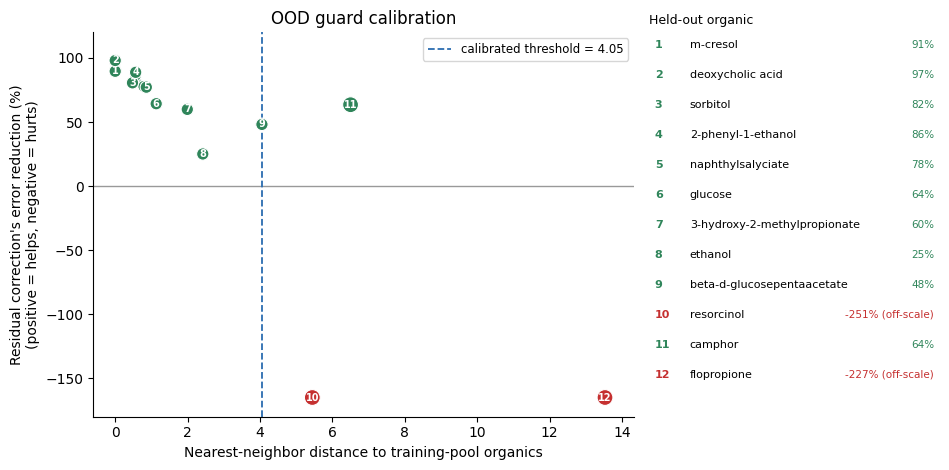

saved figs/fig3_ood_guard_calibration.png


In [14]:
# Numbered markers (sorted by distance) + a side legend, instead of inline chemical-name labels --
# with several organics clustered at low distance, inline text labels overlap badly. Numbers stay short
# enough to place right next to each point with no collisions, and the legend spells out the names.
order = sorted(per_organic.items(), key=lambda kv: kv[1]["dist"])
numbered = {name: i + 1 for i, (name, _) in enumerate(order)}

fig, (ax, ax_leg) = plt.subplots(1, 2, figsize=(9.6, 4.8), gridspec_kw={"width_ratios": [2.6, 1.4]})
dists_plot = np.array([v["dist"] for name, v in order])
reds = np.array([v["reduction_pct"] for name, v in order])
YMIN, YMAX = -180, 120
XMIN, XMAX = -0.6, float(dists_plot.max()) + 0.8
reds_clipped = np.clip(reds, YMIN + 15, YMAX)
colors = ["#2f855a" if r > 0 else "#c53030" for r in reds]
ax.scatter(dists_plot, reds_clipped, s=75, c=colors, edgecolors="white", linewidths=0.9, zorder=3)

# Collision-avoidance: nudge label positions apart in normalized plot units when two markers sit too
# close together, then draw a short leader line from the true marker to any label that had to move.
xr, yr = (XMAX - XMIN), (YMAX - YMIN)
lab_x, lab_y = dists_plot / xr, reds_clipped / yr
min_sep = 0.028
for _ in range(200):
    moved = False
    for i in range(len(lab_x)):
        for j in range(i + 1, len(lab_x)):
            dx, dy = lab_x[i] - lab_x[j], lab_y[i] - lab_y[j]
            d = (dx ** 2 + dy ** 2) ** 0.5
            if d < min_sep:
                moved = True
                if d < 1e-9:
                    dx, dy = 0.0, 1.0
                    d = 1.0
                push = (min_sep - d) / 2
                lab_x[i] += dx / d * push; lab_y[i] += dy / d * push
                lab_x[j] -= dx / d * push; lab_y[j] -= dy / d * push
    if not moved:
        break
lab_x_data, lab_y_data = lab_x * xr, lab_y * yr

for k, (name, v) in enumerate(order):
    x0, y0 = dists_plot[k], reds_clipped[k]
    lx, ly = lab_x_data[k], lab_y_data[k]
    if ((lx - x0) ** 2 + (ly - y0) ** 2) ** 0.5 > 0.012 * max(xr, yr):
        ax.plot([x0, lx], [y0, ly], color="#999", linewidth=0.6, zorder=2)
    ax.annotate(str(numbered[name]), (lx, ly), ha="center", va="center", fontsize=7,
                fontweight="bold", color="white", zorder=4,
                bbox=dict(boxstyle="circle,pad=0.12", fc=colors[k], ec="white", lw=0.8))
ax.set_xlim(XMIN, XMAX)
ax.axhline(0, color="#999", linewidth=1, zorder=1)
ax.axvline(best_t, color="#2b6cb0", linestyle="--", linewidth=1.3, zorder=2,
           label=f"calibrated threshold = {best_t:.2f}")
ax.set_ylim(YMIN, YMAX)
ax.set_xlabel("Nearest-neighbor distance to training-pool organics")
ax.set_ylabel("Residual correction's error reduction (%)\n(positive = helps, negative = hurts)")
ax.set_title("OOD guard calibration")
ax.legend(fontsize=8.5, loc="upper right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax_leg.axis("off")
y0_leg = 0.98
for name, v in order:
    num = numbered[name]
    helps = v["reduction_pct"] > 0
    color = "#2f855a" if helps else "#c53030"
    tag = f"{v['reduction_pct']:.0f}%" if v["reduction_pct"] >= YMIN + 15 else f"{v['reduction_pct']:.0f}% (off-scale)"
    ax_leg.text(0.02, y0_leg, f"{num}", fontsize=8, fontweight="bold", color=color,
                transform=ax_leg.transAxes, va="top")
    ax_leg.text(0.14, y0_leg, name, fontsize=8, transform=ax_leg.transAxes, va="top")
    ax_leg.text(0.98, y0_leg, tag, fontsize=7.5, color=color, transform=ax_leg.transAxes, va="top", ha="right")
    y0_leg -= 0.078
ax_leg.set_title("Held-out organic", fontsize=9, loc="left")

fig.tight_layout()
fig.savefig("figs/fig3_ood_guard_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figs/fig3_ood_guard_calibration.png")


## Step 6 — Final guarded pipeline: compare to Option A on the hardest case

In [15]:
X = np.stack([r["x"] for r in gen_both_unseen])
resid = predict_residual(X)
dist_per_row = np.array([gen_dist[r["organic"]] for r in gen_both_unseen])
apply_corr = dist_per_row <= best_t

print(f"=== Hardest generalization case: unseen organic AND unseen salt (n={len(gen_both_unseen)}) ===")
for i, sp in enumerate(["H2O", "organic", "cation", "anion"]):
    truth = np.array([r[f"truth_{sp}"] for r in gen_both_unseen])
    pred_a = np.array([r[f"pred_{sp}"] for r in gen_both_unseen])
    mask = apply_corr if sp == "organic" else np.ones_like(apply_corr, dtype=bool)
    pred_c_guarded = pred_a + resid[:, i] * mask
    print(f"  {sp:10s}  Option A MAE={np.mean(np.abs(truth - pred_a)):.4f}   "
          f"Option C (guarded) MAE={np.mean(np.abs(truth - pred_c_guarded)):.4f}")

print()
print("Recommended pipeline: always apply the water/ion residual correction; apply the organic-species")
print("correction only when nn_distance <= calibrated threshold, otherwise keep Option A's raw value.")


=== Hardest generalization case: unseen organic AND unseen salt (n=288) ===
  H2O         Option A MAE=0.0467   Option C (guarded) MAE=0.0568
  organic     Option A MAE=0.6145   Option C (guarded) MAE=0.3047
  cation      Option A MAE=0.6916   Option C (guarded) MAE=0.1222
  anion       Option A MAE=0.5362   Option C (guarded) MAE=0.1339

Recommended pipeline: always apply the water/ion residual correction; apply the organic-species
correction only when nn_distance <= calibrated threshold, otherwise keep Option A's raw value.


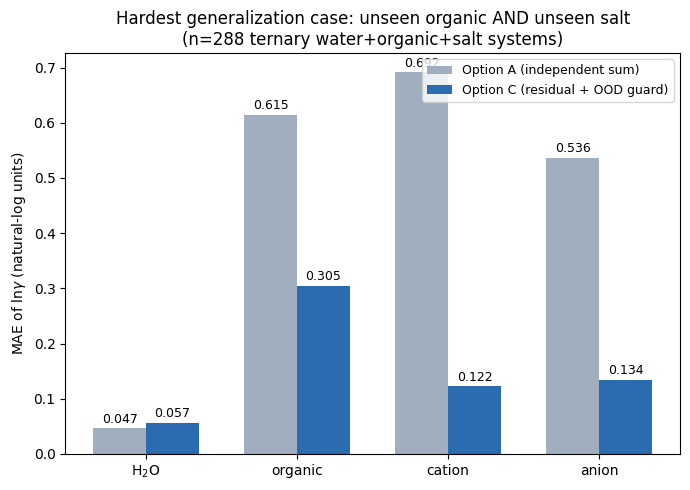

saved figs/fig2_option_a_vs_c.png


In [16]:
species = ["H2O", "organic", "cation", "anion"]
labels = [r"H$_2$O", "organic", "cation", "anion"]
mae_a_vals = [np.mean(np.abs(np.array([r[f"truth_{sp}"] for r in gen_both_unseen]) -
                              np.array([r[f"pred_{sp}"] for r in gen_both_unseen]))) for sp in species]
mae_c_vals = []
for i, sp in enumerate(species):
    truth = np.array([r[f"truth_{sp}"] for r in gen_both_unseen])
    pred_a = np.array([r[f"pred_{sp}"] for r in gen_both_unseen])
    mask = apply_corr if sp == "organic" else np.ones_like(apply_corr, dtype=bool)
    pred_c_guarded = pred_a + resid[:, i] * mask
    mae_c_vals.append(np.mean(np.abs(truth - pred_c_guarded)))

x = np.arange(len(species))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, mae_a_vals, width, label="Option A (independent sum)", color="#a0aec0")
ax.bar(x + width/2, mae_c_vals, width, label="Option C (residual + OOD guard)", color="#2b6cb0")
for i, (a, c) in enumerate(zip(mae_a_vals, mae_c_vals)):
    ax.text(i - width/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)
    ax.text(i + width/2, c + 0.01, f"{c:.3f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel(r"MAE of ln$\gamma$ (natural-log units)")
ax.set_title(f"Hardest generalization case: unseen organic AND unseen salt\n(n={len(gen_both_unseen)} ternary water+organic+salt systems)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig("figs/fig2_option_a_vs_c.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figs/fig2_option_a_vs_c.png")


## Step 7 — Validation against published AIOMFAC worked examples (paper Sec. 4.5)

As a check tied to the literature rather than to this notebook's own random held-out
split, run the guarded Option C pipeline on two ternary systems used as worked examples
in Zuend et al. (2011): water + malonic acid + (NH4)2SO4 (their Fig. 3) and water +
ethanol + KCl (their Fig. 7, compared there to EMF-derived data of Lopes et al., 1999).
Malonic acid was also flagged in Part 1 (Sec. 8) as the hardest generalization case for
the organic surrogate on its own binary system.

In [17]:
def nn_distance_feat(feat22):
    """Same nearest-neighbor-distance guard check as Step 5, for an organic not
    necessarily present in organics.json / by_name (e.g. malonic acid below)."""
    f = (feat22 - f_mean) / f_std
    return float(np.sqrt(((train_feats_n - f[None, :]) ** 2).sum(axis=1)).min())


def worked_example(smiles, organic_name, cat_name, an_name, wtf_organic_grid, wtf_salt_grid, T_K=298.15):
    feat22, subgroups = organic_mg_features(smiles)
    dist = nn_distance_feat(feat22)
    apply_organic_corr = dist <= best_t
    print(f"{organic_name}: nearest-neighbor distance = {dist:.2f}  "
          f"(guard threshold {best_t:.2f}) -> organic correction "
          f"{'APPLIED' if apply_organic_corr else 'SKIPPED (falls back to Option A)'}")

    rows = []
    for wtf_o in wtf_organic_grid:
        for wtf_s in wtf_salt_grid:
            gt = ternary_ground_truth(smiles, organic_name, subgroups, cat_name, an_name, wtf_o, wtf_s, T_K)
            if gt is None:
                continue
            truth, ctx = gt
            pred = option_a_predict(feat22, cat_name, an_name, ctx, T_K)
            T_norm = (T_K - 293.15) / 20.0
            cat_oh = [1.0 if n == cat_name else 0.0 for n in CATION_NAMES]
            an_oh = [1.0 if n == an_name else 0.0 for n in ANION_NAMES]
            x = np.concatenate([feat22, [wtf_o, wtf_s, T_norm, np.log1p(ctx["molal_cat"]),
                                          np.log1p(ctx["molal_an"])], cat_oh, an_oh]).astype(np.float32)
            rows.append({"wtf_organic": wtf_o, "wtf_salt": wtf_s, "x": x,
                         "truth_H2O": truth["ln_gamma_H2O"], "pred_H2O": pred["ln_gamma_H2O"],
                         "truth_organic": truth["ln_gamma_organic"], "pred_organic": pred["ln_gamma_organic"],
                         "truth_cation": truth[f"ln_gamma_{cat_name}"], "pred_cation": pred[f"ln_gamma_{cat_name}"],
                         "truth_anion": truth[f"ln_gamma_{an_name}"], "pred_anion": pred[f"ln_gamma_{an_name}"]})

    X = np.stack([r["x"] for r in rows])
    resid = predict_residual(X)
    results = {"n": len(rows), "dist": dist, "apply_organic_corr": apply_organic_corr, "rows": rows}
    for i, sp in enumerate(["H2O", "organic", "cation", "anion"]):
        truth = np.array([r[f"truth_{sp}"] for r in rows])
        pred_a = np.array([r[f"pred_{sp}"] for r in rows])
        mask = apply_organic_corr if sp == "organic" else True
        pred_c = pred_a + resid[:, i] * mask
        mae_a, mae_c = float(np.mean(np.abs(truth - pred_a))), float(np.mean(np.abs(truth - pred_c)))
        results[sp] = {"mae_a": mae_a, "mae_c": mae_c, "pred_c": pred_c, "truth": truth}
        print(f"  {sp:10s}  Option A MAE={mae_a:.4f}   Option C (guarded) MAE={mae_c:.4f}")
    return results


**Table 8.** Twelve water + malonic acid + (NH4)2SO4 compositions (water-mass fraction
of malonic acid 0.03-0.15, of the salt 0.02-0.08, 298.15 K).

In [18]:
table8 = worked_example("OC(=O)CC(=O)O", "malonic acid", "NH4+", "SO4--",
                         wtf_organic_grid=[0.03, 0.06, 0.09, 0.12, 0.15],
                         wtf_salt_grid=[0.02, 0.05, 0.08])
print(f"\n(n={table8['n']} compositions)")


malonic acid: nearest-neighbor distance = 2.35  (guard threshold 4.05) -> organic correction APPLIED
  H2O         Option A MAE=0.0184   Option C (guarded) MAE=0.0418
  organic     Option A MAE=0.8539   Option C (guarded) MAE=0.8790
  cation      Option A MAE=0.0452   Option C (guarded) MAE=0.0515
  anion       Option A MAE=0.1751   Option C (guarded) MAE=0.0740

(n=15 compositions)


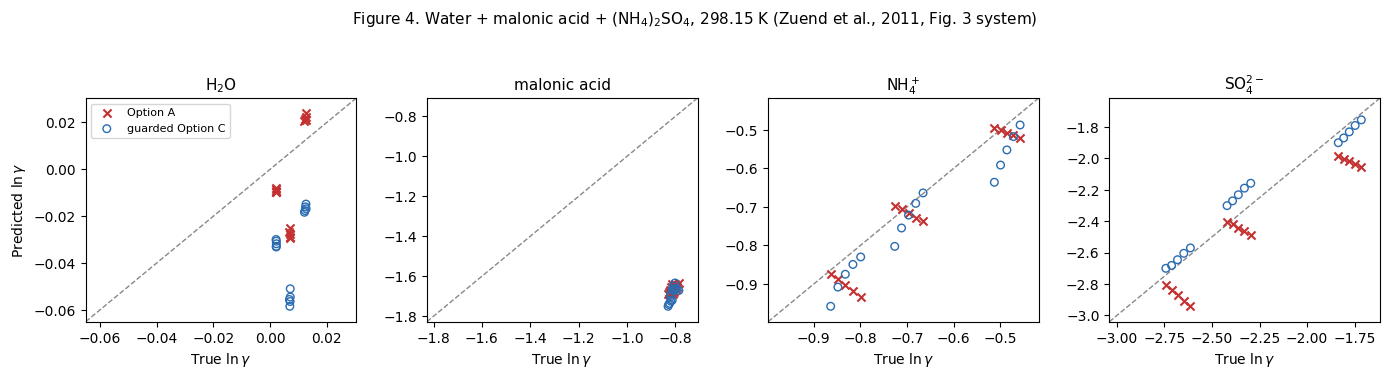

saved figs/fig4_malonic_parity.png


In [19]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=False)
species = ["H2O", "organic", "cation", "anion"]
labels = [r"H$_2$O", "malonic acid", r"NH$_4^+$", r"SO$_4^{2-}$"]
for ax, sp, lab in zip(axes, species, labels):
    truth, pred_a, pred_c = table8[sp]["truth"], np.array([r[f"pred_{sp}"] for r in table8["rows"]]), table8[sp]["pred_c"]
    lo, hi = min(truth.min(), pred_a.min(), pred_c.min()), max(truth.max(), pred_a.max(), pred_c.max())
    pad = 0.08 * (hi - lo + 1e-6)
    lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "--", color="#888888", linewidth=1, zorder=1)
    ax.scatter(truth, pred_a, s=34, color="#c53030", marker="x", label="Option A", zorder=2)
    ax.scatter(truth, pred_c, s=30, color="#2b6cb0", marker="o", facecolors="none", label="guarded Option C", zorder=3)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(r"True $\ln\gamma$")
    if ax is axes[0]:
        ax.set_ylabel(r"Predicted $\ln\gamma$")
        ax.legend(loc="upper left", fontsize=8, frameon=True)
    ax.set_title(lab, fontsize=11)
fig.suptitle("Figure 4. Water + malonic acid + (NH$_4$)$_2$SO$_4$, 298.15 K (Zuend et al., 2011, Fig. 3 system)",
             fontsize=11, y=1.04)
fig.tight_layout()
fig.savefig("figs/fig4_malonic_parity.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figs/fig4_malonic_parity.png")


**Table 9.** Thirteen water + ethanol + KCl compositions (fixed salt mass fraction 0.03,
ethanol mass fraction 0.05-0.45, 298.15 K), compared on the mean molal activity
coefficient `gamma_+/- = sqrt(gamma_cation * gamma_anion)`, the quantity Zuend et al.
(2011, Fig. 7) actually plot against the EMF-derived data of Lopes et al. (1999).

In [20]:
ethanol_wtf_grid = np.round(np.linspace(0.05, 0.45, 13), 3)
table9 = worked_example("OCC", "ethanol", "K+", "Cl-",
                         wtf_organic_grid=ethanol_wtf_grid, wtf_salt_grid=[0.03])
print(f"\n(n={table9['n']} compositions)")

gamma_pm_truth = np.sqrt(np.exp(table9["cation"]["truth"]) * np.exp(table9["anion"]["truth"]))
gamma_pm_a = np.sqrt(np.exp(np.array([r["pred_cation"] for r in table9["rows"]])) *
                      np.exp(np.array([r["pred_anion"] for r in table9["rows"]])))
gamma_pm_c = np.sqrt(np.exp(table9["cation"]["pred_c"]) * np.exp(table9["anion"]["pred_c"]))
mae_pm_a = float(np.mean(np.abs(gamma_pm_truth - gamma_pm_a)))
mae_pm_c = float(np.mean(np.abs(gamma_pm_truth - gamma_pm_c)))
rel_a = 100 * mae_pm_a / np.mean(gamma_pm_truth)
rel_c = 100 * mae_pm_c / np.mean(gamma_pm_truth)
print(f"\ngamma_+/- (mean molal)  Option A MAE={mae_pm_a:.3f} ({rel_a:.1f}%)   "
      f"Option C (guarded) MAE={mae_pm_c:.3f} ({rel_c:.1f}%)")


ethanol: nearest-neighbor distance = 2.42  (guard threshold 4.05) -> organic correction APPLIED
  H2O         Option A MAE=0.0149   Option C (guarded) MAE=0.0051
  organic     Option A MAE=0.0481   Option C (guarded) MAE=0.1044
  cation      Option A MAE=1.0113   Option C (guarded) MAE=0.0396
  anion       Option A MAE=0.6907   Option C (guarded) MAE=0.0149

(n=13 compositions)

gamma_+/- (mean molal)  Option A MAE=0.968 (60.6%)   Option C (guarded) MAE=0.048 (3.0%)


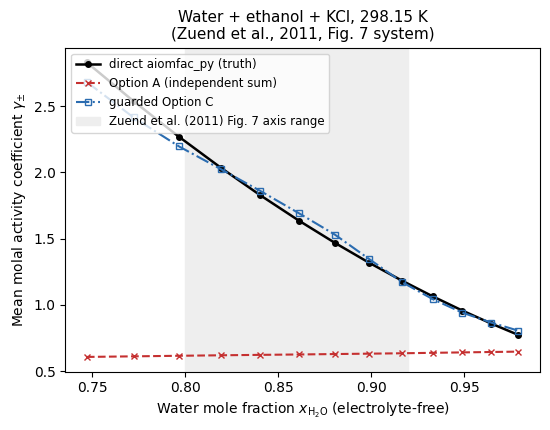

saved figs/fig5_ethanol_kcl_gammapm.png


In [21]:
x_water_mole = []
for r in table9["rows"]:
    wtf_o, wtf_s = r["wtf_organic"], r["wtf_salt"]
    wtf_w = 1.0 - wtf_o - wtf_s
    n_w, n_o = wtf_w / 18.015, wtf_o / 46.07
    x_water_mole.append(n_w / (n_w + n_o))  # electrolyte-free water mole fraction
x_water_mole = np.array(x_water_mole)
order = np.argsort(x_water_mole)

fig, ax = plt.subplots(figsize=(5.6, 4.4))
ax.plot(x_water_mole[order], gamma_pm_truth[order], "-", color="k", linewidth=1.8, marker="o", markersize=4,
        label="direct aiomfac_py (truth)")
ax.plot(x_water_mole[order], gamma_pm_a[order], "--", color="#c53030", linewidth=1.5, marker="x", markersize=5,
        label="Option A (independent sum)")
ax.plot(x_water_mole[order], gamma_pm_c[order], "-.", color="#2b6cb0", linewidth=1.5, marker="s", markersize=4,
        markerfacecolor="none", label="guarded Option C")
ax.axvspan(0.80, 0.92, color="#eee", zorder=0, label="Zuend et al. (2011) Fig. 7 axis range")
ax.set_xlabel(r"Water mole fraction $x_{\mathrm{H_2O}}$ (electrolyte-free)")
ax.set_ylabel(r"Mean molal activity coefficient $\gamma_{\pm}$")
ax.set_title("Water + ethanol + KCl, 298.15 K\n(Zuend et al., 2011, Fig. 7 system)", fontsize=11)
ax.legend(loc="upper left", fontsize=8.5, frameon=True)
fig.tight_layout()
fig.savefig("figs/fig5_ethanol_kcl_gammapm.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved figs/fig5_ethanol_kcl_gammapm.png")


**Summary of Sec. 4.5.** Water and the sulfate ion both land within a few hundredths of
a log unit of truth either way in Table 8, and the guarded correction roughly halves the
sulfate error; water and the ammonium ion are the two species where the correction does
not help on this particular worked example -- a reminder that the residual model's
average benefit (Table 7) is not guaranteed to transfer to every individual system, even
an in-guard one. The organic's own ln(gamma) remains the weak point for malonic acid,
consistent with Part 1's binary-only check of the same compound. For ethanol + KCl
(Table 9), Option A's independent sum fails qualitatively for the ions at this higher
electrolyte concentration (essentially flat with composition), while the guarded
correction tracks both the level and the shape of the true gamma_+/- curve -- the
clearest demonstration in either paper that the residual correction is not a marginal
refinement but what makes the combined surrogate usable once electrolyte concentration
moves away from the dilute limit.

## Summary

- **Option A** (independent sum, no retraining of either surrogate): essentially exact for water
  (cross-term error ~0.007), but the organic's own gamma and especially the ions' gamma are dominated by a
  real cross-term (ion-organic salting-in/out) the additive sum cannot see.
- **Option C** (add one small residual model): closes almost all of that gap in-distribution (93-98%
  reduction), and generalizes well to unseen salts and unseen ion chemistry even with brand-new organics
  (76-98% reduction) — but widening the training pool 6x does *not* fix generalization of the organic's own
  correction to a genuinely novel organic; more data of the same kind does not help there.
- **OOD guard**: a simple nearest-neighbor-distance check on the organic-species correction alone recovers
  Option C's benefit (correctly separates 11/12 held-out organics into "correction helps" vs. "correction
  hurts") without ever making the organic's own prediction worse than Option A's raw value.

This notebook reproduces the organic-inorganic combination section of the paper end to end.
